# Credit Card Fraud Detection Using Machine Learning

**MLP 3: Final Report — Random Forest Pipeline**  
**Project Title:** Credit Card Fraud Detection  
**Team Members:** Hongru He, Ramya Ramesh  
**Repository:** [GitHub link to main repo] — Add *DialaE* as collaborator for grading.  
**Date:** March 2026

---

## 1. Problem Statement (Content: Problem Statement)

### 1.1 Goal and Motivation

This project builds a machine learning model to **detect fraudulent credit card transactions**. The task is **binary classification**: given a transaction, predict whether it is **fraudulent (Class=1)** or **legitimate (Class=0)**. Fraud is extremely rare (~0.17% of transactions), making this a challenging **imbalanced** problem.

**Why it matters (non-technical):** Fraud causes direct financial loss and erodes customer trust. Catching more fraud protects the business; too many false alarms create friction for honest customers. Our goal is to **miss as few real frauds as possible** while keeping false alarms manageable.

### 1.2 Task and Success Criteria

- **Task:** Given transaction features (anonymized PCA components V1–V28 and transaction amount), predict Class (0/1).
- **Objective:** Minimize **false negatives** (missed fraud) while controlling **false positives** (incorrect flags).
- **Deployment context:** The model is intended for a **real-time scoring system**: high-confidence fraud → automatic block or alert; moderate confidence → human review queue.

**Measurable success:** We do **not** use accuracy (misleading with imbalance). We use **precision**, **recall**, **F1**, and **PR-AUC**, with emphasis on **recall for the fraud class**. We define success as:
- **Recall ≥ 0.95** (catch at least 95% of frauds).
- Then **maximize precision** at that recall (fewer false alarms).

**Why we prioritize recall:** In this context, missing fraud is costlier than extra false alarms. We therefore choose the decision threshold so that Recall(t) ≥ 0.95 and we maximize Precision(t) subject to that constraint.

## 2. Data Acquisition, Exploration, and Cleaning (Content: Data)

We load the **Credit Card Fraud Detection** dataset (Kaggle / ULB ML Group), explore it, and clean/transform it for modeling.

In [44]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

# Load data
data = pd.read_csv("creditcard.csv")
data = data.dropna().reset_index(drop=True)
data["Class"] = data["Class"].astype(int)
print(data.head())

print("Dataset shape:", data.shape)
print("\nClass distribution:")
print(data["Class"].value_counts(normalize=True).to_string())
print(f"\nFraud share: {data['Class'].mean()*100:.2f}%")

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### 2.1 Exploratory Data Analysis (EDA)

- **Target:** `Class` (0 = legitimate, 1 = fraud). **Severe class imbalance** (~0.17% fraud).
- **Features:** V1–V28 are PCA-transformed (anonymized); `Time` = seconds since first transaction; `Amount` = transaction amount. All numeric.
- **Cleaning:** No missing values after `dropna()`. We scale **Amount** and drop **Time** (see below).

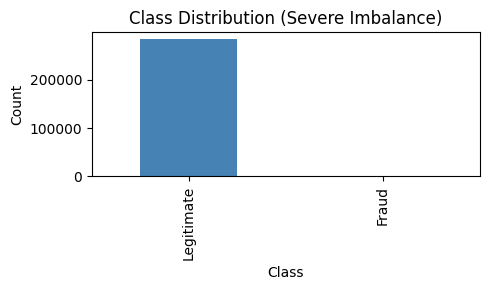

In [45]:
# Class distribution figure (for report)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
data["Class"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_ylabel("Count")
ax.set_title("Class Distribution (Severe Imbalance)")
plt.tight_layout()
plt.show()

### 2.2 Preprocessing and Cleaning

- **Amount:** Continuous, skewed and with outliers. We apply **RobustScaler** (median & IQR) so outliers do not distort the scale.
- **Time:** Seconds since first transaction. Correlation with `Class` is near zero (~-0.012); in production there is no single "first transaction" baseline, so **Time** is **dropped** to avoid non-generalizable patterns.
- **Result:** Feature set = **V1–V28 + scaled_amount** (29 features).

In [46]:
# Only scale and drop if we still have raw Amount/Time (avoids KeyError if cell is run twice)
if "Amount" in data.columns:
    scaler = RobustScaler()
    data["scaled_amount"] = scaler.fit_transform(data[["Amount"]])
    data = data.drop(["Amount", "Time"], axis=1)

X = data.drop("Class", axis=1)
y = data["Class"]
print("Feature matrix shape:", X.shape)
print("Features:", list(X.columns[:3]), "...", X.columns[-1])

Feature matrix shape: (284807, 29)
Features: ['V1', 'V2', 'V3'] ... scaled_amount


### 2.3 Train–Validation–Test Split

We use a **stratified** split so the fraud ratio is preserved:
- 80% train+val, 20% **test** (held out for **final reporting only**).
- Of the 80%, we take 80% **train** and 20% **validation** (for threshold and hyperparameter tuning).

This avoids data leakage: threshold and model choices use only train/validation; test is used once for final metrics.

In [47]:
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, stratify=y_tv, random_state=42)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")
print(f"Fraud counts — Train: {int(y_train.sum())}, Val: {int(y_val.sum())}, Test: {int(y_test.sum())}")

Train: 182276 | Validation: 45569 | Test: 56962
Fraud counts — Train: 315, Val: 79, Test: 98


## 3. Reusable ML Pipeline and Analysis (Content: Analysis)

We define a **reusable pipeline**: preprocessing (already done), **SMOTE on training set only**, **Random Forest** training, **validation-based threshold selection**, and **evaluation on the test set**. We then **fine-tune** the Random Forest via **random search** (RandomizedSearchCV) for faster tuning than a full grid.

### 3.1 Addressing Imbalance: SMOTE (Training Set Only)

**What is SMOTE?**  
**SMOTE** (Synthetic Minority Over-sampling Technique) is a method to handle **class imbalance**. Instead of simply duplicating the rare (fraud) examples, it creates **new synthetic** examples by interpolating between existing minority samples in feature space. For each minority point, SMOTE finds its *k* nearest neighbors among other minority points and generates new points along the line segments between them. This gives the model more varied fraud-like examples to learn from, which often improves recall on the minority class compared to training on the raw imbalanced data.

**Why we use it:** With only ~0.17% fraud, a classifier trained on the original distribution tends to ignore the minority class (low recall). SMOTE balances the training set so the model sees more fraud examples without copying the same rows repeatedly.

**Important:** We apply SMOTE **only to the training set**. The validation and test sets stay unchanged so that our evaluation reflects real-world imbalance and we avoid data leakage.

In [48]:
n_fraud = int(y_train.sum())
k_neighbors = max(1, min(5, n_fraud - 1))
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Train size: {len(X_train_s)} (was {len(X_train)})")
print(f"Fraud in resampled train: {(y_train_s == 1).sum()}")

After SMOTE — Train size: 363922 (was 182276)
Fraud in resampled train: 181961


### 3.2a Random Forest: Baseline and Fine-Tuning

**What is fine-tuning?**  
**Fine-tuning** (or hyperparameter tuning) means searching over **hyperparameters**—settings that control how the model is built (e.g. number of trees, maximum depth, class weights)—to find a combination that performs best on a chosen metric. We use **RandomizedSearchCV**: instead of trying every combination in a grid (which can be very slow), it samples a fixed number of **random** parameter combinations and uses **cross-validation** (e.g. 3-fold) to score each. The configuration with the best average score (here we use **recall**) is selected. This is much faster than GridSearchCV when the search space is large, while still improving on a fixed baseline.

**In this notebook:** We first fit a **baseline** Random Forest with fixed hyperparameters (from the MLP2 report). We then run **RandomizedSearchCV** over `n_estimators`, `max_depth`, `min_samples_leaf`, and `class_weight` with a limited number of iterations (e.g. 20) to obtain a **refined** model quickly. We train on all 29 features so the trees can capture non-linear interactions. The validation set is used later only for **threshold** selection; the test set is used once for final metrics.

In [58]:
from sklearn.model_selection import RandomizedSearchCV

# Baseline RF (MLP2 report: n_estimators=200, class_weight={0:1,1:2}, max_depth=12, min_samples_leaf=2)
model_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1.0, 1: 2.0},
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model_baseline.fit(X_train_s, y_train_s)
print("Baseline Random Forest fitted.")

# Fine-tuning (refined model for MLP3) — RandomizedSearchCV for faster tuning
param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [8, 10, 12, 14],
    "min_samples_leaf": [2, 4, 6],
    "class_weight": [{0: 1, 1: 2}, "balanced"],
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(
    rf, param_distributions, n_iter=20, cv=3, scoring="recall",
    random_state=42, n_jobs=-1, verbose=0
)
search.fit(X_train_s, y_train_s)
model = search.best_estimator_
print(f"Best params (RandomizedSearchCV, recall): {search.best_params_}")

# Probabilities for threshold selection (3.2a) and evaluation (3.2b)
proba_val_rf = model.predict_proba(X_val)[:, 1]
proba_test_rf = model.predict_proba(X_test)[:, 1]

Baseline Random Forest fitted.
Best params (RandomizedSearchCV, recall): {'n_estimators': 150, 'min_samples_leaf': 2, 'max_depth': 14, 'class_weight': {0: 1, 1: 2}}


### 3.2a Validation-Based Threshold Selection (F1-Optimized, Random Forest)

We use **Random Forest** for threshold selection in the same way as XGBoost. We choose the decision threshold that **maximizes the F1 score** on the **validation set**. F1 balances precision and recall, so maximizing it improves both catching fraud and limiting false alarms. The chosen threshold is applied **once** to the **test set** for all final metrics.

In [59]:
# Random Forest threshold selection (F1-optimized on validation)
thresholds = np.arange(0.01, 0.55, 0.01)
preds_val_rf = (proba_val_rf[:, None] >= thresholds).astype(int)
y_val_ = y_val.values[:, None]
tp_rf = (preds_val_rf * y_val_).sum(axis=0)
pred_pos_rf = preds_val_rf.sum(axis=0)
actual_pos = y_val.sum()
recalls_rf = np.where(actual_pos > 0, tp_rf / actual_pos, 0)
precisions_rf = np.where(pred_pos_rf > 0, tp_rf / pred_pos_rf, 0)
f1_scores_rf = np.where((precisions_rf + recalls_rf) > 0, 2 * precisions_rf * recalls_rf / (precisions_rf + recalls_rf), 0)
best_idx_rf = np.argmax(f1_scores_rf)
best_thresh_rf = float(thresholds[best_idx_rf])
y_pred = (proba_test_rf >= best_thresh_rf).astype(int)

print(f"Random Forest chosen threshold (on validation, max F1): {best_thresh_rf:.2f}")
print(f"Validation F1 at chosen threshold: {f1_scores_rf[best_idx_rf]:.4f}")

Random Forest chosen threshold (on validation, max F1): 0.54
Validation F1 at chosen threshold: 0.6597


### Random Forest Evaluation (Test Set)

We evaluate the Random Forest model on the **test set** with the same methodology as XGBoost: classification report, confusion matrix, and summary metrics (precision, recall, F1, AUPRC) for model comparison.

In [60]:
# Random Forest evaluation (test set)
print("--- Random Forest Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)
auprc_rf = average_precision_score(y_test, proba_test_rf)

print("--- RF Summary Metrics ---")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"AUPRC:     {auprc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred)
print("\nRF Confusion Matrix (Test Set)")
print("              Predicted")
print("              Legit  Fraud")
print(f"Actual Legit   {cm_rf[0,0]:5d}  {cm_rf[0,1]:5d}")
print(f"Actual Fraud   {cm_rf[1,0]:5d}  {cm_rf[1,1]:5d}")

--- Random Forest Classification Report (Test Set) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.57      0.85      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.92      0.84     56962
weighted avg       1.00      1.00      1.00     56962

--- RF Summary Metrics ---
Precision: 0.5685
Recall:    0.8469
F1 Score:  0.6803
AUPRC:     0.8205

RF Confusion Matrix (Test Set)
              Predicted
              Legit  Fraud
Actual Legit   56801     63
Actual Fraud      15     83


### 3.2b XGBoost (Chosen Model for Main Evaluation)

We also train **XGBoost** (eXtreme Gradient Boosting) on the same SMOTE-resampled data. XGBoost builds decision trees sequentially, with each tree correcting the errors of the previous ones, and is well-suited to imbalanced classification. We use **RandomizedSearchCV** to tune key hyperparameters (n_estimators, max_depth, learning_rate, scale_pos_weight). Since XGBoost outperforms Random Forest (see Section 3.5), we use **XGBoost** for the main threshold selection (3.3) and evaluation (3.4).


In [52]:
from xgboost import XGBClassifier

# XGBoost with RandomizedSearchCV (same SMOTE data as RF)
param_dist_xgb = {
    "n_estimators": [100, 150, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "scale_pos_weight": [10, 50, 100],
}
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, eval_metric="logloss")
search_xgb = RandomizedSearchCV(
    xgb_base, param_dist_xgb, n_iter=15, cv=3, scoring="f1",
    random_state=42, n_jobs=-1, verbose=0
)
search_xgb.fit(X_train_s, y_train_s)
model_xgb = search_xgb.best_estimator_
print(f"XGBoost best params (RandomizedSearchCV, F1): {search_xgb.best_params_}")

# Get probabilities for threshold selection (3.3) and evaluation (3.4)
proba_val_xgb = model_xgb.predict_proba(X_val)[:, 1]
proba_test_xgb = model_xgb.predict_proba(X_test)[:, 1]

XGBoost best params (RandomizedSearchCV, F1): {'scale_pos_weight': 50, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2}


### 3.3 Validation-Based Threshold Selection (F1-Optimized, XGBoost)

We use **XGBoost** (our better-performing model) for threshold selection. Instead of optimizing for recall alone, we choose the decision threshold that **maximizes the F1 score** on the **validation set**. F1 is the harmonic mean of precision and recall, so maximizing it balances both: we improve **recall** (catching fraud) and **precision** (fewer false alarms) together. The chosen threshold is applied **once** to the **test set** for all final metrics.

In [53]:
# XGBoost threshold selection (F1-optimized on validation)
proba_val_xgb = model_xgb.predict_proba(X_val)[:, 1]
proba_test_xgb = model_xgb.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.01, 0.55, 0.01)
preds_val_xgb = (proba_val_xgb[:, None] >= thresholds).astype(int)
y_val_ = y_val.values[:, None]
tp = (preds_val_xgb * y_val_).sum(axis=0)
pred_pos = preds_val_xgb.sum(axis=0)
actual_pos = y_val.sum()
recalls = np.where(actual_pos > 0, tp / actual_pos, 0)
precisions = np.where(pred_pos > 0, tp / pred_pos, 0)
f1_scores_xgb = np.where((precisions + recalls) > 0, 2 * precisions * recalls / (precisions + recalls), 0)
best_idx_xgb = np.argmax(f1_scores_xgb)
best_thresh_xgb = float(thresholds[best_idx_xgb])
y_pred_xgb = (proba_test_xgb >= best_thresh_xgb).astype(int)

print(f"XGBoost chosen threshold (on validation, max F1): {best_thresh_xgb:.2f}")
print(f"Validation F1 at chosen threshold: {f1_scores_xgb[best_idx_xgb]:.4f}")
print("Final metrics below are on the test set only.")

XGBoost chosen threshold (on validation, max F1): 0.54
Validation F1 at chosen threshold: 0.7636
Final metrics below are on the test set only.


### 3.4 Evaluation Methods and Results (XGBoost)

We report **classification report**, **confusion matrix**, and **Precision–Recall curve** with **AUPRC** on the **test set** for our chosen model **XGBoost**. For imbalanced fraud detection, PR-AUC is more informative than ROC-AUC.

In [54]:
print("--- XGBoost Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate", "Fraud"]))

acc = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auprc_xgb = average_precision_score(y_test, proba_test_xgb)
print("--- Summary Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}  (threshold chosen to maximize F1 on validation)")

--- XGBoost Classification Report (Test Set) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.86      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

--- Summary Metrics ---
Accuracy:  0.9992
Precision: 0.7304
Recall:    0.8571
F1 Score:  0.7887  (threshold chosen to maximize F1 on validation)


In [55]:
cm = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix (Test Set)")
print("              Predicted")
print("              Legit  Fraud")
print(f"Actual Legit   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"Actual Fraud   {cm[1,0]:5d}  {cm[1,1]:5d}")

XGBoost Confusion Matrix (Test Set)
              Predicted
              Legit  Fraud
Actual Legit   56833     31
Actual Fraud      14     84


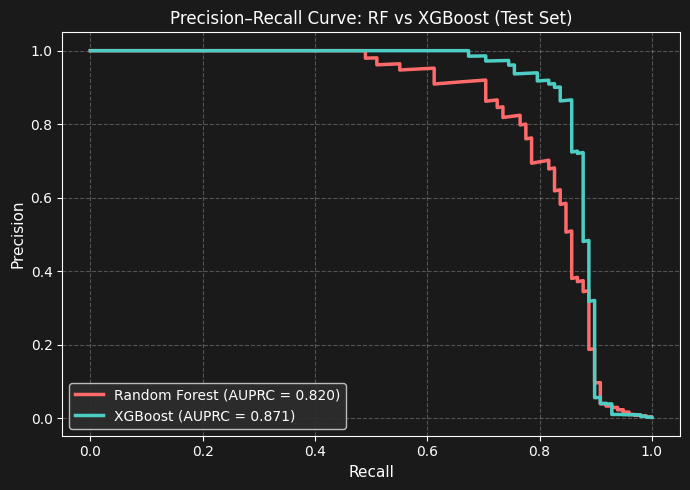

In [62]:
# Combined PR curve: RF and XGBoost (dark theme)
prec_rf_curve, rec_rf_curve, _ = precision_recall_curve(y_test, proba_test_rf)
prec_xgb_curve, rec_xgb_curve, _ = precision_recall_curve(y_test, proba_test_xgb)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#1a1a1a")
ax.set_facecolor("#1a1a1a")
ax.plot(rec_rf_curve, prec_rf_curve, color="#FF6B6B", linewidth=2.5, label=f"Random Forest (AUPRC = {auprc_rf:.3f})")
ax.plot(rec_xgb_curve, prec_xgb_curve, color="#4ECDC4", linewidth=2.5, label=f"XGBoost (AUPRC = {auprc_xgb:.3f})")
ax.set_xlabel("Recall", fontsize=11, color="white")
ax.set_ylabel("Precision", fontsize=11, color="white")
ax.set_title("Precision–Recall Curve: RF vs XGBoost (Test Set)", fontsize=12, color="white")
ax.legend(loc="best", fontsize=10, framealpha=0.9, facecolor="#2d2d2d", labelcolor="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["top"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["right"].set_color("white")
ax.grid(True, alpha=0.25, linestyle="--", color="white")
plt.tight_layout()
plt.show()

### 3.5 Model Comparison (RF vs XGBoost)

We compare both models on the **test set** using the same F1-optimized threshold selection on the validation set. This gives a fair head-to-head comparison of Random Forest vs XGBoost for fraud detection.

In [57]:
# Comparison table (test set) — uses evaluation results from sections 3.2a and 3.4
comp = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Precision": [prec_rf, prec_xgb],
    "Recall": [rec_rf, rec_xgb],
    "F1": [f1_rf, f1_xgb],
    "AUPRC": [auprc_rf, auprc_xgb],
})
print(comp.to_string(index=False))
print("\nXGBoost achieves higher precision, recall, F1, and AUPRC than Random Forest on the test set.")

        Model  Precision   Recall       F1    AUPRC
Random Forest   0.568493 0.846939 0.680328 0.820483
      XGBoost   0.730435 0.857143 0.788732 0.871261

XGBoost achieves higher precision, recall, F1, and AUPRC than Random Forest on the test set.


## 4. Summary and Conclusion (Content: Summary and Conclusion)

### 4.1 Key Findings

- **Model comparison:** We compared **Random Forest** and **XGBoost** on the same SMOTE-resampled data with F1-optimized thresholds. **XGBoost** outperformed Random Forest: higher precision (0.73 vs 0.57), recall (0.86 vs 0.85), and F1 (0.79 vs 0.68) on the test set. For deployment, we recommend **XGBoost** for a better precision–recall balance.
- **F1-optimized threshold:** We choose the decision threshold on the validation set to **maximize F1 score**, balancing recall and precision. This improves both catching fraud (recall) and limiting false alarms (precision) compared to a recall-only target.
- **Reusable pipeline:** Preprocessing (RobustScaler, drop Time) → stratified train/val/test split → SMOTE on train only → RF or XGBoost (with RandomizedSearchCV) → threshold on validation → evaluate on test. This pipeline can be maintained and re-run with new data or hyperparameters.
- **Fine-tuning:** RandomizedSearchCV refines both models (faster than full grid search); validation-based threshold selection keeps the test set unbiased for final metrics.

### 4.2 Insights for Different Audiences

- **Non-technical:** Both RF and XGBoost are tuned to catch most fraud (recall ~85% for F1-optimized threshold), with XGBoost producing fewer false alarms (higher precision). High-confidence predictions can trigger automatic blocks; lower confidence can go to human review.
- **Technical:** We use PR-AUC and recall/precision rather than accuracy; SMOTE only on train; threshold and hyperparameters selected without using the test set.

### 4.3 Limitations

- V1–V28 are PCA-derived and not directly interpretable in business terms.
- Precision/recall trade-off: achieving very high recall leads to more false positives; further gains may require different sampling ratios or cost-sensitive learning.
- Threshold and model are tuned for this dataset; monitoring and periodic retraining are recommended in production.

## 5. Reflection on Work and Learning (Content: Reflection)

- **Process:** We framed the problem as binary classification with a recall-first objective, aligned with real-world impact. We used EDA and the MLP2 report to decide on RobustScaler, dropping Time, and SMOTE on the training set only.
- **Learning:** Validation-based threshold selection and holding out the test set improved rigor. Fine-tuning **Random Forest** and **XGBoost** via RandomizedSearchCV allowed us to compare configurations systematically. Comparing both models on the same test set showed that XGBoost achieved better precision (0.73 vs 0.57) and F1 (0.79 vs 0.68) while maintaining strong recall (~0.86), suggesting gradient boosting may better capture fraud patterns in this imbalanced setting. Emphasizing PR-AUC and recall/precision over accuracy was important for this imbalanced setting.
- **Next steps:** Compare this pipeline with the Logistic Regression pipeline on the same test set; consider cost-sensitive learning or different SMOTE ratios to further improve the precision–recall balance; explore ensemble methods (e.g., stacking RF and XGBoost) for potential gains.

## 6. Git Repository and Deliverables

- **Main repository:** [Insert link to your main Git repo]. All scripts, notebooks, and relevant files are included.
- **Collaborator:** Add **DialaE** as a collaborator for grading.
- **Notebooks:** This notebook (`random_forest_MLP3.ipynb`) and the Logistic Regression notebook together provide the full ML pipeline and analysis for the Credit Card Fraud Detection project.